<a href="https://colab.research.google.com/github/Lidia-Kibret/Financial-Inclusion-Zindi/blob/main/Financial%20Inclusion%20In%20Africa(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Financial Inclusion in Africa

## Dataset Overview

The Financial Inclusion in Africa dataset contains demographic, social, and economic information about individuals across different countries. It is used to understand and predict whether a person has access to a bank account.



## Objective

The goal of this project is to analyze the dataset and build a machine learning model that predicts financial inclusion status.

Specifically, the focus is on:

✔️ Understanding factors that influence bank account ownership

✔️ Exploring relationships between demographic features and financial access

✔️ Identifying patterns across countries and regions

✔️ Building a predictive model for classification



## Observations

✔️ The dataset contains both categorical and numerical features

✔️ The target variable is binary (bank account: Yes/No)

✔️ The dataset is imbalanced, with more individuals not having bank accounts

✔️ No missing values are present in the dataset

✔️ Features such as education level, job type, and cellphone access are important indicators of financial inclusion

- This step mounts Google Drive to access files within the Colab environment.

In [309]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Data Loading

The dataset is loaded from Google Drive into pandas DataFrames.


## 1.1 Importing Libraries

The following libraries are used in this project:

- **pandas, numpy** → data manipulation and numerical operations  
- **seaborn, matplotlib** → data visualization  
- **scikit-learn** → preprocessing, model training, and evaluation  
- **XGBoost** → advanced machine learning model for classification  

In [390]:
# Data handling

import pandas as pd
import numpy as np
import math



# Visualization

import seaborn as sns
import matplotlib.pyplot as plt

# ML

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier # Added LightGBM
import lightgbm as lgb # Added import for early stopping
from pandas_profiling import ProfileReport

import warnings
warnings.filterwarnings('ignore')


## 1.2 Load the CSV Files

- **Train dataset**: Contains features and target variable (`bank_account`)
- **Test dataset**: Contains only features (used for prediction)
- **Sample submission**: Shows required output format
- **Variable definitions**: Provides description of each feature

In [311]:
# Load files into pandas DataFrames

path = "/content/drive/MyDrive/Colab Notebooks/Data/"

train = pd.read_csv(path + "Train.csv")
test = pd.read_csv(path + "Test.csv")
ss = pd.read_csv(path + "SampleSubmission.csv")
variables = pd.read_csv(path + "VariableDefinitions.csv")




In [312]:
# Let us check the first five rows of the train dataset
train.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [313]:
# Lets us confirm the definitions of the features
var_def = pd.read_csv(path + "VariableDefinitions.csv")
var_def.columns = ["Variable", "Definition"]
var_def

,Variable,Definition
0,country,Country interviewee is in.
1,year,Year survey was done in.
2,uniqueid,Unique identifier for each interviewee
3,location_type,"Type of location: Rural, Urban"
4,cellphone_access,"If interviewee has access to a cellphone: Yes, No"
5,household_size,Number of people living in one house
6,age_of_respondent,The age of the interviewee
7,gender_of_respondent,"Gender of interviewee: Male, Female"
8,relationship_with_head,The interviewee’s relationship with the head o...
9,marital_status,The martial status of the interviewee: Married...


In [314]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


In [315]:
train.nunique().sort_values(ascending=False).reset_index(name="uniqe_value")



,index,uniqe_value
0,uniqueid,8735
1,age_of_respondent,85
2,household_size,20
3,job_type,10
4,relationship_with_head,6
5,education_level,6
6,marital_status,5
7,country,4
8,year,3
9,location_type,2


In [316]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10086 entries, 0 to 10085
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 10086 non-null  object
 1   year                    10086 non-null  int64 
 2   uniqueid                10086 non-null  object
 3   location_type           10086 non-null  object
 4   cellphone_access        10086 non-null  object
 5   household_size          10086 non-null  int64 
 6   age_of_respondent       10086 non-null  int64 
 7   gender_of_respondent    10086 non-null  object
 8   relationship_with_head  10086 non-null  object
 9   marital_status          10086 non-null  object
 10  education_level         10086 non-null  object
 11  job_type                10086 non-null  object
dtypes: int64(3), object(9)
memory usage: 945.7+ KB


## Country Feature

In [317]:
train['country'].describe()

,country
count,23524
unique,4
top,Rwanda
freq,8735


In [318]:
train['country'].unique()

array(['Kenya', 'Rwanda', 'Tanzania', 'Uganda'], dtype=object)

In [319]:
train['country'].value_counts().reset_index(name="count")

,country,count
0,Rwanda,8735
1,Tanzania,6620
2,Kenya,6068
3,Uganda,2101


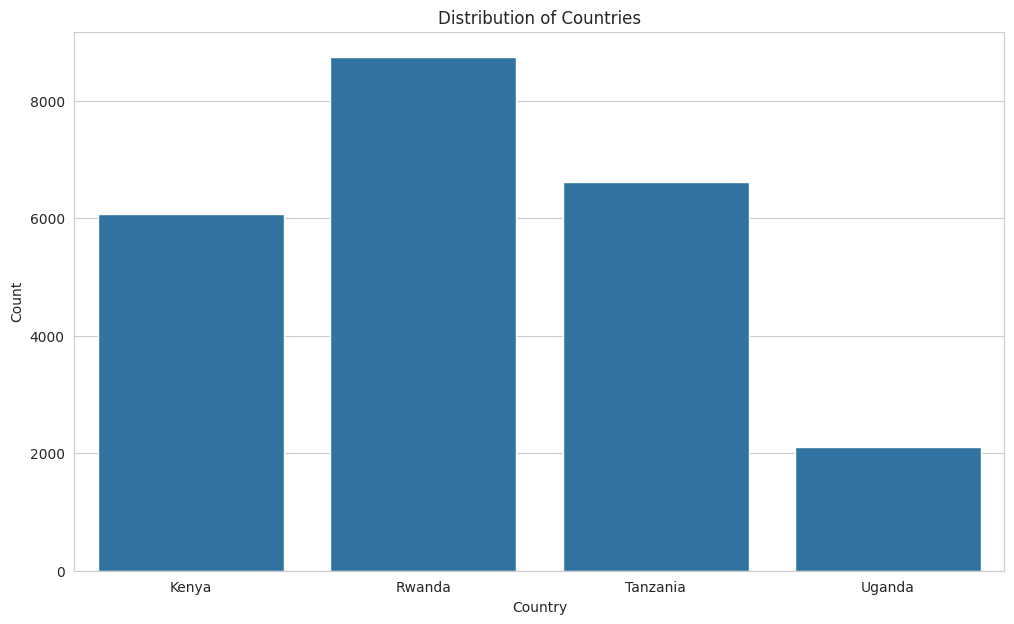

In [320]:
plt.figure(figsize=(12, 7))
sns.countplot(x='country', data=train)
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Distribution of Countries')
plt.show()

In [321]:
train.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


## Phone_Access Feature

In [322]:
train['cellphone_access'].describe()

,cellphone_access
count,23524
unique,2
top,Yes
freq,17454


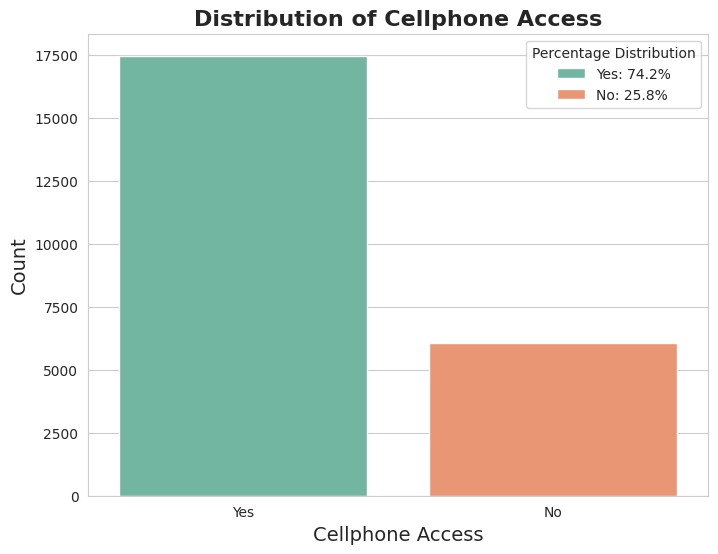

In [323]:
# Calculate percentage distribution
value_counts = train['cellphone_access'].value_counts()
percentages = (value_counts / value_counts.sum()) * 100

# Visualizing the distribution of values in the 'cellphone_access' column
plt.figure(figsize=(8, 6))
sns.set_style('whitegrid')

# Creating the countplot
sns.countplot(
    x='cellphone_access',
    data=train,
    palette='Set2'
)

# Adding labels and title
plt.xlabel('Cellphone Access', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Distribution of Cellphone Access', fontsize=16, fontweight='bold')

# Adding a legend with percentage distribution
legend_labels = [f'{label}: {percent:.1f}%' for label, percent in zip(value_counts.index, percentages)]
plt.legend(legend_labels, title='Percentage Distribution', loc='upper right')

# Display the plot
plt.show()


In [324]:
train.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


## Unique Id Feature

In [325]:
# Drop the 'uniqueid' column
train = train.drop(columns=['uniqueid'])

# Verify the column has been dropped
print(train.head())

  country  year bank_account location_type cellphone_access  household_size  \
0   Kenya  2018          Yes         Rural              Yes               3   
1   Kenya  2018           No         Rural               No               5   
2   Kenya  2018          Yes         Urban              Yes               5   
3   Kenya  2018           No         Rural              Yes               5   
4   Kenya  2018           No         Urban               No               8   

   age_of_respondent gender_of_respondent relationship_with_head  \
0                 24               Female                 Spouse   
1                 70               Female      Head of Household   
2                 26                 Male         Other relative   
3                 34               Female      Head of Household   
4                 26                 Male                  Child   

            marital_status                  education_level  \
0  Married/Living together              Secondary edu

In [326]:
## Education_Status

In [327]:
train['education_level'].describe()

,education_level
count,23524
unique,6
top,Primary education
freq,12791


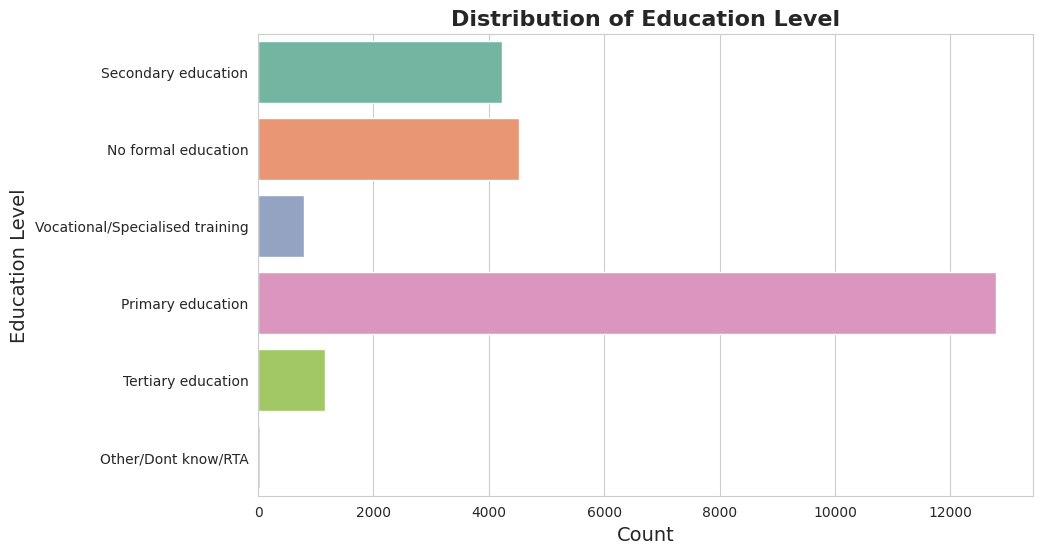

In [328]:
plt.figure(figsize=(10, 6))
sns.countplot(y='education_level', data=train, palette='Set2')

plt.xlabel('Count', fontsize=14)
plt.ylabel('Education Level', fontsize=14)
plt.title('Distribution of Education Level', fontsize=16, fontweight='bold')

plt.show()

In [329]:
train.head()

,country,year,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


## Job_Category

In [330]:
train['job_type'].describe()

,job_type
count,23524
unique,10
top,Self employed
freq,6437


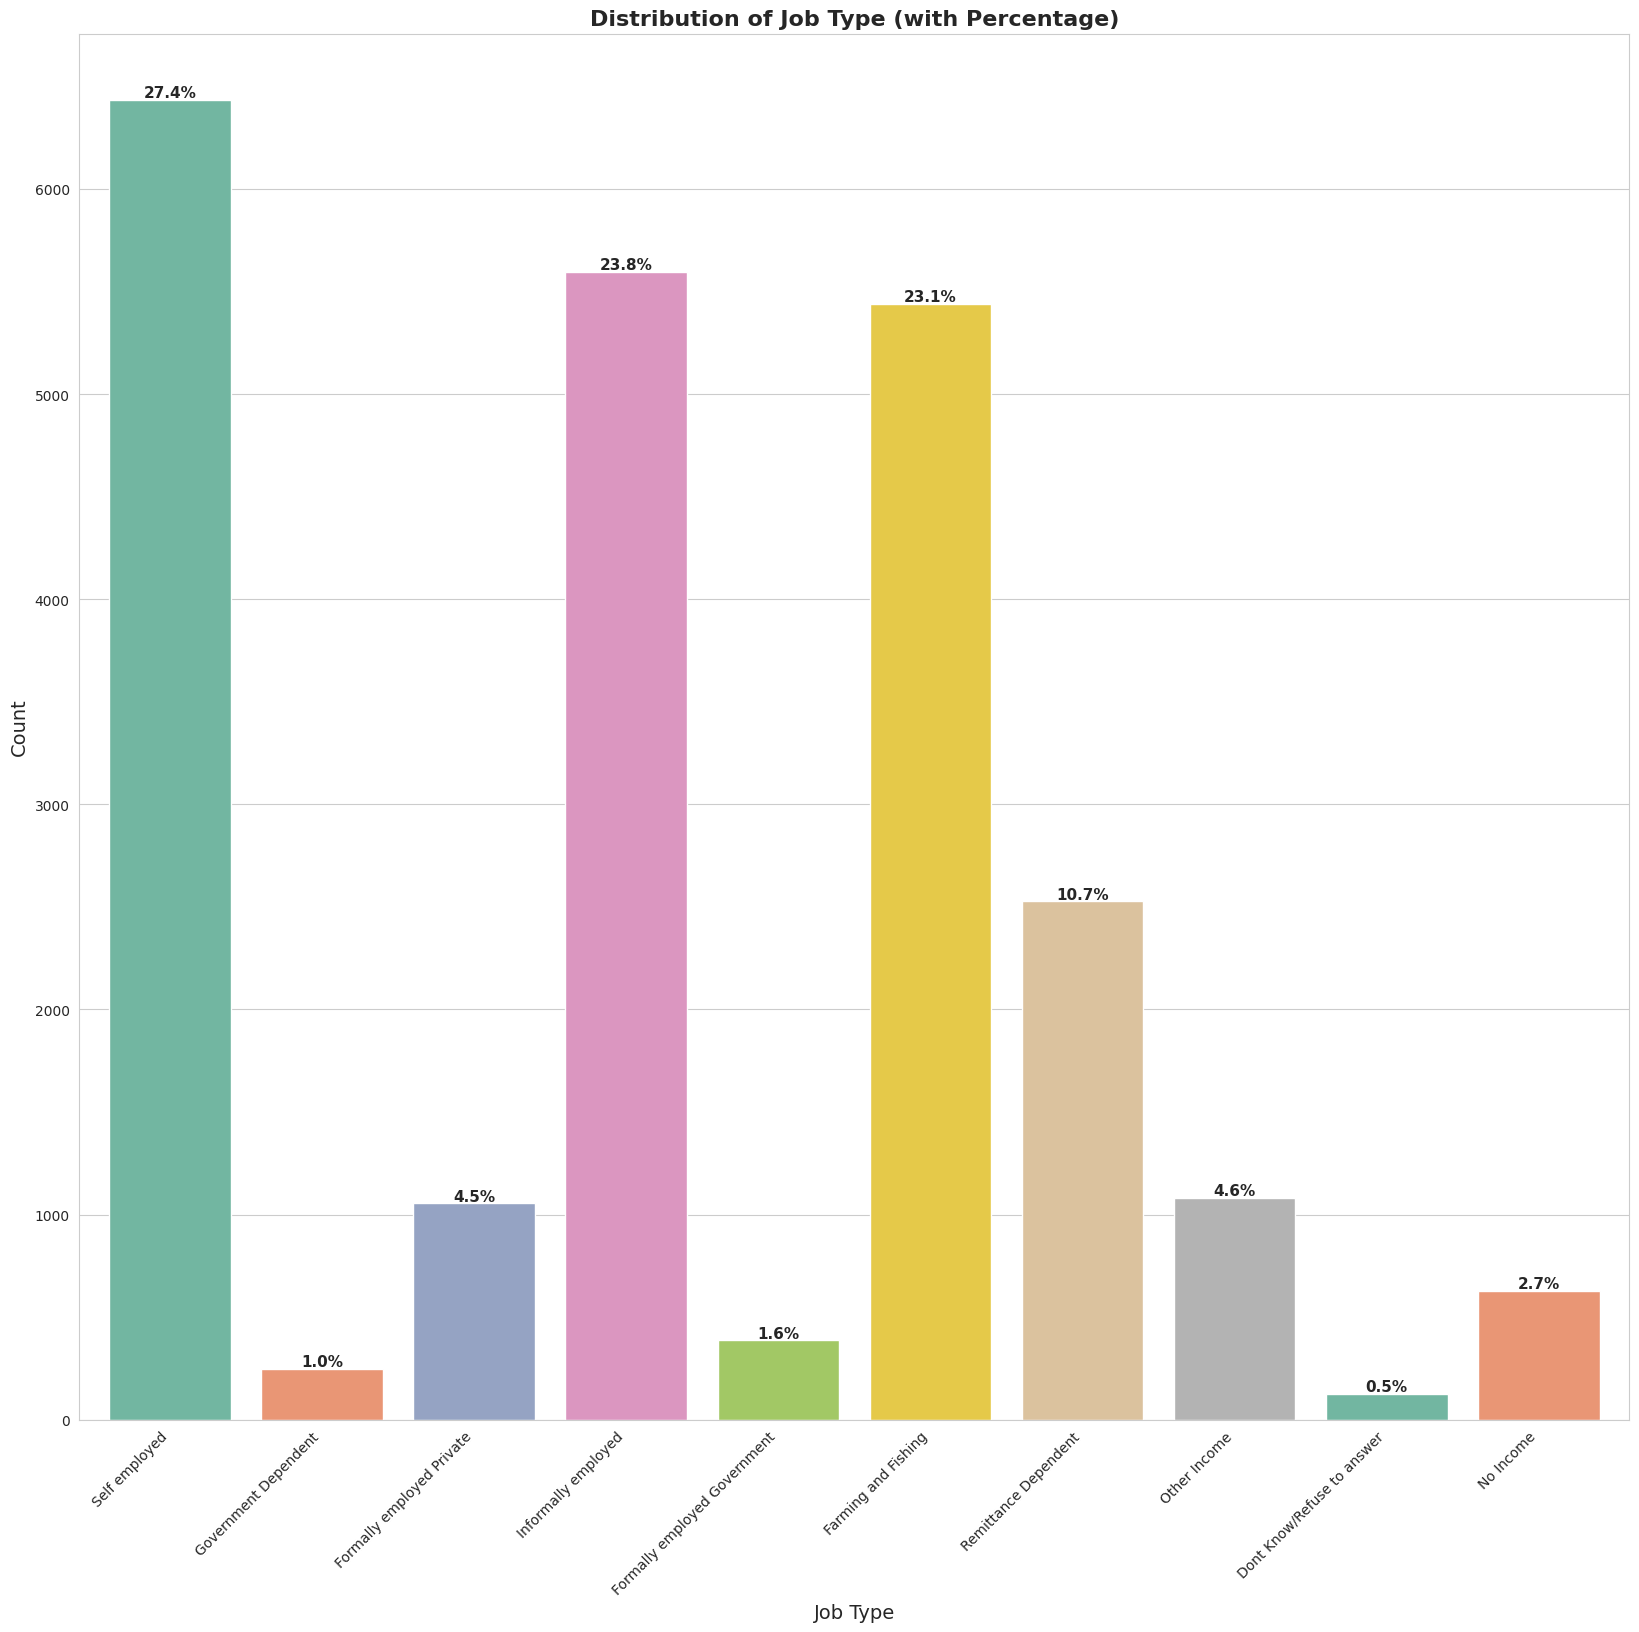

In [331]:
plt.figure(figsize=(20, 18))

value_counts = train['job_type'].value_counts()
percentages = (value_counts / value_counts.sum()) * 100

ax = sns.countplot(x='job_type', data=train, palette='Set2')

# Add percentages on bars
for p in ax.patches:
    height = p.get_height()
    percentage = (height / len(train)) * 100
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center',
                fontsize=11, fontweight='bold',
                xytext=(0, 5),
                textcoords='offset points')

# 📌 Improve x-axis spacing
plt.xticks(rotation=45, ha='right')   # 👈 key fix for space
plt.margins(x=0.02)                   # 👈 adds side spacing

plt.xlabel('Job Type', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Distribution of Job Type (with Percentage)', fontsize=16, fontweight='bold')

plt.show()

## Area_Type

In [332]:
train['location_type'].describe()

,location_type
count,23524
unique,2
top,Rural
freq,14343


In [333]:
train['location_type'].value_counts().reset_index(name="count")

,location_type,count
0,Rural,14343
1,Urban,9181


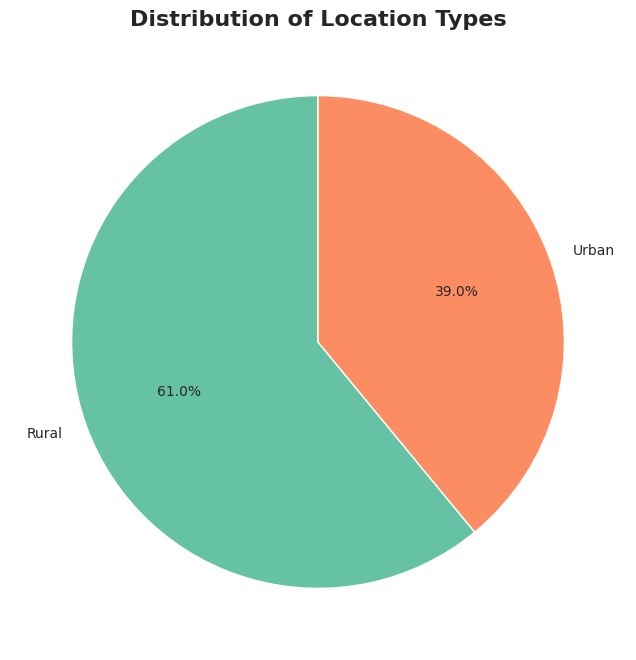

In [334]:
plt.figure(figsize=(8, 8))

location_counts = train['location_type'].value_counts()

plt.pie(
    location_counts,
    labels=location_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66c2a5', '#fc8d62']  # 👈 soft academic colors
)

plt.title('Distribution of Location Types', fontsize=16, fontweight='bold')
plt.show()

## Family_Size

In [335]:
train['household_size'].describe()

,household_size
count,23524.000000
mean,3.797483
std,2.227613
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,21.000000


In [336]:
train['household_size'].value_counts()

,count
household_size,
2,5229
3,3920
4,3474
1,3057
5,2853
6,2096
7,1400
8,751
9,363


In [337]:
print(train['household_size'].value_counts())
print(train['household_size'].value_counts().get(1, 0))
print(train['household_size'].value_counts().get(21, 0))

household_size
2     5229
3     3920
4     3474
1     3057
5     2853
6     2096
7     1400
8      751
9      363
10     190
11      69
12      68
13      25
15      11
14      10
16       4
21       1
18       1
17       1
20       1
Name: count, dtype: int64
3057
1


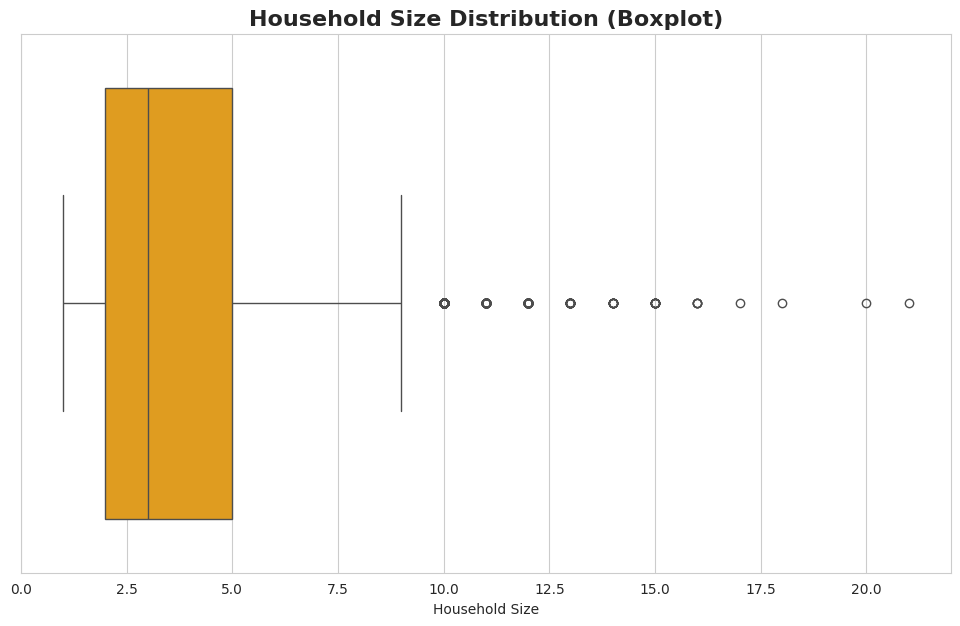

In [338]:
plt.figure(figsize=(12, 7))
sns.boxplot(x=train['household_size'], color='orange')

plt.title('Household Size Distribution (Boxplot)', fontsize=16, fontweight='bold')
plt.xlabel('Household Size')
plt.show()

In [339]:
# Define more readable bins
bins = [0, 2, 4, 6, 10, float('inf')]
labels = ['Small (1-2)', 'Medium (3-4)', 'Large (5-6)', 'Very Large (7-10)', 'Extreme (10+)']

# Apply binning
train['household_size_group'] = pd.cut(
    train['household_size'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Check distribution
train['household_size_group'].value_counts().reset_index(name="count")

,household_size_group,count
0,Small (1-2),8286
1,Medium (3-4),7394
2,Large (5-6),4949
3,Very Large (7-10),2704
4,Extreme (10+),191


In [340]:
train.head()

,country,year,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,household_size_group
0,Kenya,2018,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed,Medium (3-4)
1,Kenya,2018,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent,Large (5-6)
2,Kenya,2018,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed,Large (5-6)
3,Kenya,2018,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private,Large (5-6)
4,Kenya,2018,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed,Very Large (7-10)


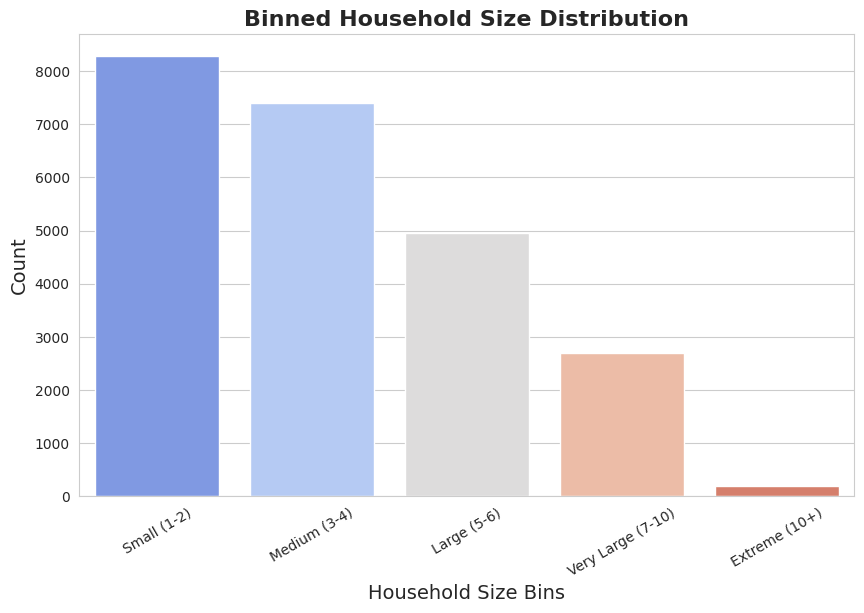

In [341]:
plt.figure(figsize=(10, 6))

order = train['household_size_group'].value_counts().index

sns.countplot(
    x='household_size_group',
    data=train,
    order=order,
    palette='coolwarm'
)

plt.xlabel('Household Size Bins', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Binned Household Size Distribution', fontsize=16, fontweight='bold')
plt.xticks(rotation=30)

plt.show()

In [342]:
# Dropping the household_size column
train = train.drop(columns=['household_size'])
train.head()

,country,year,bank_account,location_type,cellphone_access,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,household_size_group
0,Kenya,2018,Yes,Rural,Yes,24,Female,Spouse,Married/Living together,Secondary education,Self employed,Medium (3-4)
1,Kenya,2018,No,Rural,No,70,Female,Head of Household,Widowed,No formal education,Government Dependent,Large (5-6)
2,Kenya,2018,Yes,Urban,Yes,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed,Large (5-6)
3,Kenya,2018,No,Rural,Yes,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private,Large (5-6)
4,Kenya,2018,No,Urban,No,26,Male,Child,Single/Never Married,Primary education,Informally employed,Very Large (7-10)


In [343]:
bins = [0, 2, 4, 6, float('inf')]
labels = ['1-2', '3-4', '5-6', '7+']

test['household_size_group'] = pd.cut(
    test['household_size'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

#
print(test['household_size_group'].value_counts())


# Display the first few rows of the updated dataset
test.head()

household_size_group
1-2    3592
3-4    3130
5-6    2159
7+     1205
Name: count, dtype: int64


,country,year,uniqueid,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,household_size_group
0,Kenya,2018,uniqueid_6056,Urban,Yes,3,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government,3-4
1,Kenya,2018,uniqueid_6060,Urban,Yes,7,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private,7+
2,Kenya,2018,uniqueid_6065,Rural,No,3,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent,3-4
3,Kenya,2018,uniqueid_6072,Rural,No,6,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent,5-6
4,Kenya,2018,uniqueid_6073,Urban,No,3,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent,3-4


In [344]:
# Dropping the household_size column
test = test.drop(columns=['household_size'])
test.head()

,country,year,uniqueid,location_type,cellphone_access,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,household_size_group
0,Kenya,2018,uniqueid_6056,Urban,Yes,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government,3-4
1,Kenya,2018,uniqueid_6060,Urban,Yes,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private,7+
2,Kenya,2018,uniqueid_6065,Rural,No,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent,3-4
3,Kenya,2018,uniqueid_6072,Rural,No,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent,5-6
4,Kenya,2018,uniqueid_6073,Urban,No,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent,3-4


## Individual_Age Feature

In [345]:
train['age_of_respondent'].describe()

,age_of_respondent
count,23524.000000
mean,38.805220
std,16.520569
min,16.000000
25%,26.000000
50%,35.000000
75%,49.000000
max,100.000000


In [346]:
train['age_of_respondent'].value_counts().reset_index(name="count")

,age_of_respondent,count
0,30,1056
1,35,836
2,25,792
3,28,748
4,32,715
...,...,...
80,91,5
81,93,4
82,96,3
83,99,2


<Axes: xlabel='age_of_respondent', ylabel='Count'>

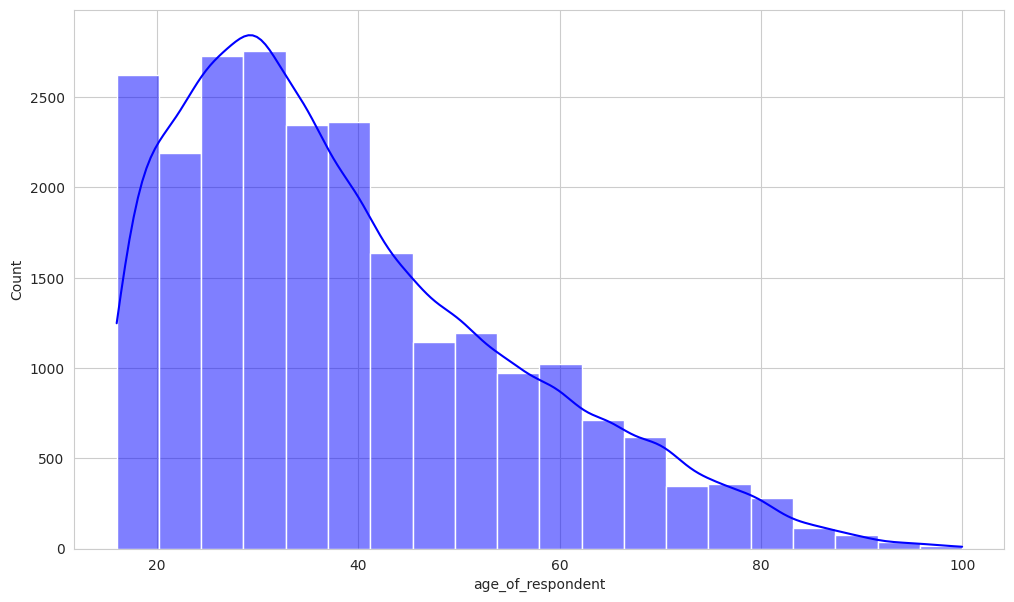

In [347]:
plt.figure(figsize=(12, 7))
sns.histplot(train['age_of_respondent'], bins=20, kde=True, color='blue')

<Axes: xlabel='age_of_respondent'>

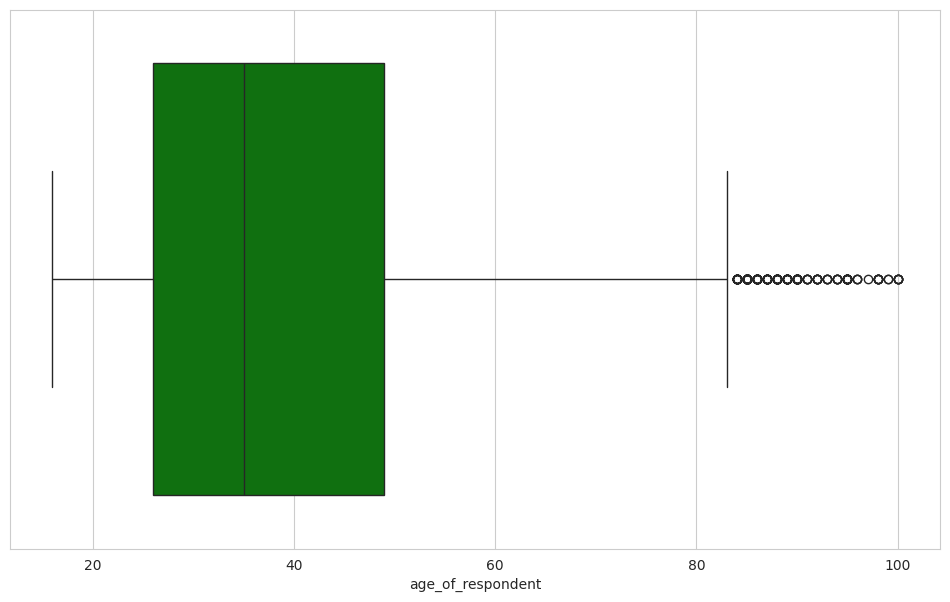

In [348]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='age_of_respondent', data=train, color='green')

In [349]:
# Apply logarithmic scaling
train['age_of_respondent_log'] = np.log1p(train['age_of_respondent'])  # np.log1p handles log(0) safely

# Display the transformed column
print(train[['age_of_respondent', 'age_of_respondent_log']].head())

   age_of_respondent  age_of_respondent_log
0                 24               3.218876
1                 70               4.262680
2                 26               3.295837
3                 34               3.555348
4                 26               3.295837


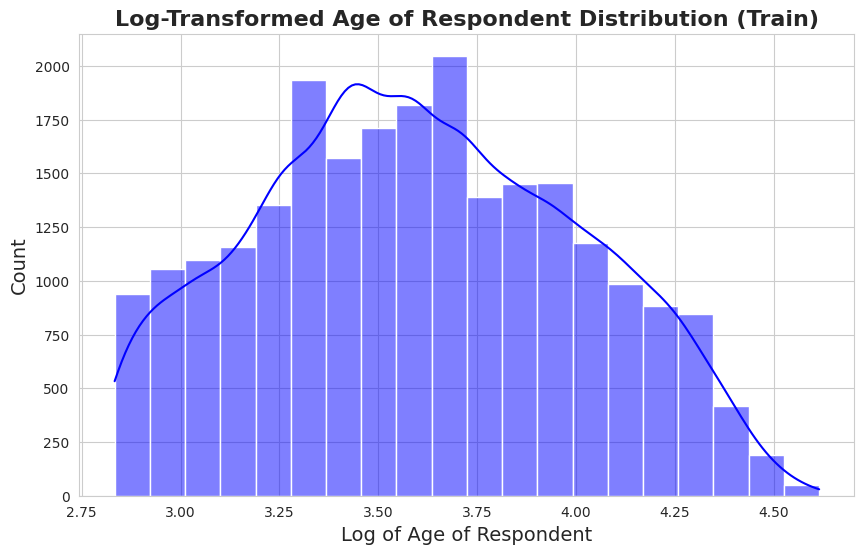

In [350]:
# Visualize the log-transformed household sizes
plt.figure(figsize=(10, 6))
sns.histplot(train['age_of_respondent_log'], kde=True, color='blue', bins=20)
plt.xlabel('Log of Age of Respondent', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Log-Transformed Age of Respondent Distribution (Train)', fontsize=16, fontweight='bold')
plt.show()

In [351]:
train = train.drop(columns=['age_of_respondent'])
train.head()

,country,year,bank_account,location_type,cellphone_access,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,household_size_group,age_of_respondent_log
0,Kenya,2018,Yes,Rural,Yes,Female,Spouse,Married/Living together,Secondary education,Self employed,Medium (3-4),3.218876
1,Kenya,2018,No,Rural,No,Female,Head of Household,Widowed,No formal education,Government Dependent,Large (5-6),4.262680
2,Kenya,2018,Yes,Urban,Yes,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed,Large (5-6),3.295837
3,Kenya,2018,No,Rural,Yes,Female,Head of Household,Married/Living together,Primary education,Formally employed Private,Large (5-6),3.555348
4,Kenya,2018,No,Urban,No,Male,Child,Single/Never Married,Primary education,Informally employed,Very Large (7-10),3.295837


   age_of_respondent  age_of_respondent_log
0                 30               3.433987
1                 51               3.951244
2                 77               4.356709
3                 39               3.688879
4                 16               2.833213


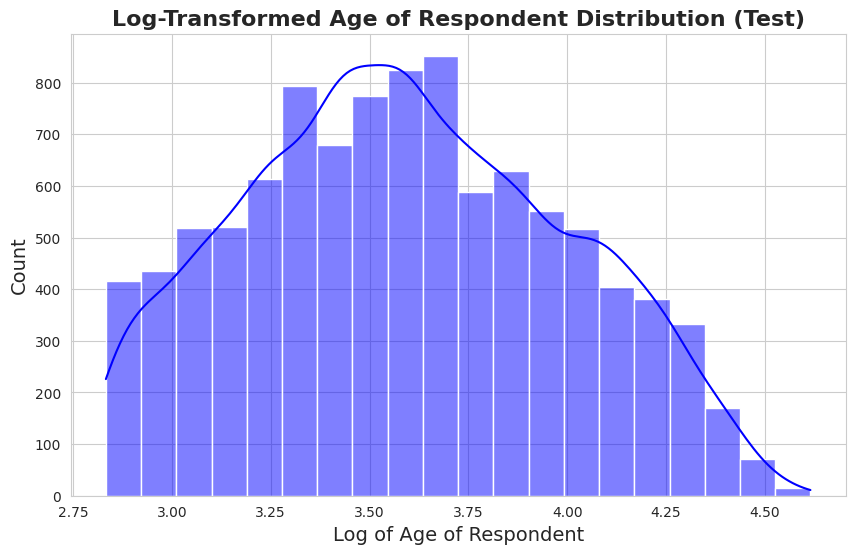

In [352]:
# Apply logarithmic scaling
test['age_of_respondent_log'] = np.log1p(test['age_of_respondent'])  # np.log1p handles log(0) safely

# Display the transformed column
print(test[['age_of_respondent', 'age_of_respondent_log']].head())

# Visualize the log-transformed household sizes
plt.figure(figsize=(10, 6))
sns.histplot(test['age_of_respondent_log'], kde=True, color='blue', bins=20)
plt.xlabel('Log of Age of Respondent', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Log-Transformed Age of Respondent Distribution (Test)', fontsize=16, fontweight='bold')
plt.show()

In [353]:
# Dropping the age_of_respondent column
test = test.drop(columns=['age_of_respondent'])
test.head()

,country,year,uniqueid,location_type,cellphone_access,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,household_size_group,age_of_respondent_log
0,Kenya,2018,uniqueid_6056,Urban,Yes,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government,3-4,3.433987
1,Kenya,2018,uniqueid_6060,Urban,Yes,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private,7+,3.951244
2,Kenya,2018,uniqueid_6065,Rural,No,Female,Parent,Married/Living together,No formal education,Remittance Dependent,3-4,4.356709
3,Kenya,2018,uniqueid_6072,Rural,No,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent,5-6,3.688879
4,Kenya,2018,uniqueid_6073,Urban,No,Male,Child,Single/Never Married,Secondary education,Remittance Dependent,3-4,2.833213


## ➡️ EDA Insights

## ✔️ Country

- The dataset includes Kenya, Rwanda, Tanzania, and Uganda. There are noticeable differences across countries, which may affect financial inclusion levels.


## Cellphone Access

- Most respondents have access to mobile phones, showing that mobile technology is widely available and important for financial services.


## Household Size

- Household sizes range from 1 to 21, but most are between 2–5 members. Extreme values were grouped into bins to improve modeling.


## Education Level

- Most respondents have primary or secondary education, while fewer have no education or higher education. Education is likely a key factor in financial inclusion.


## Job Type

- Self-employment and informal jobs dominate the dataset, suggesting many people work outside formal employment systems.


## Location Type

- A majority of respondents live in rural areas, which may limit access to banking services.


## Age

Ages range widely, with most between 25–50 years. A log transformation was applied to reduce skewness.

## ➡️ Key Takeaways

- Rural residence and informal jobs reduce financial inclusion

- Mobile phone access is high and important

- Education and employment strongly influence bank account ownership

- Data was cleaned using binning and log transformation for better modeling

## Occupation_Education

In [354]:
train['job_education'] = train['job_type'] + '_' + train['education_level']

In [355]:
test['job_education'] = test['job_type'] + '_' + test['education_level']

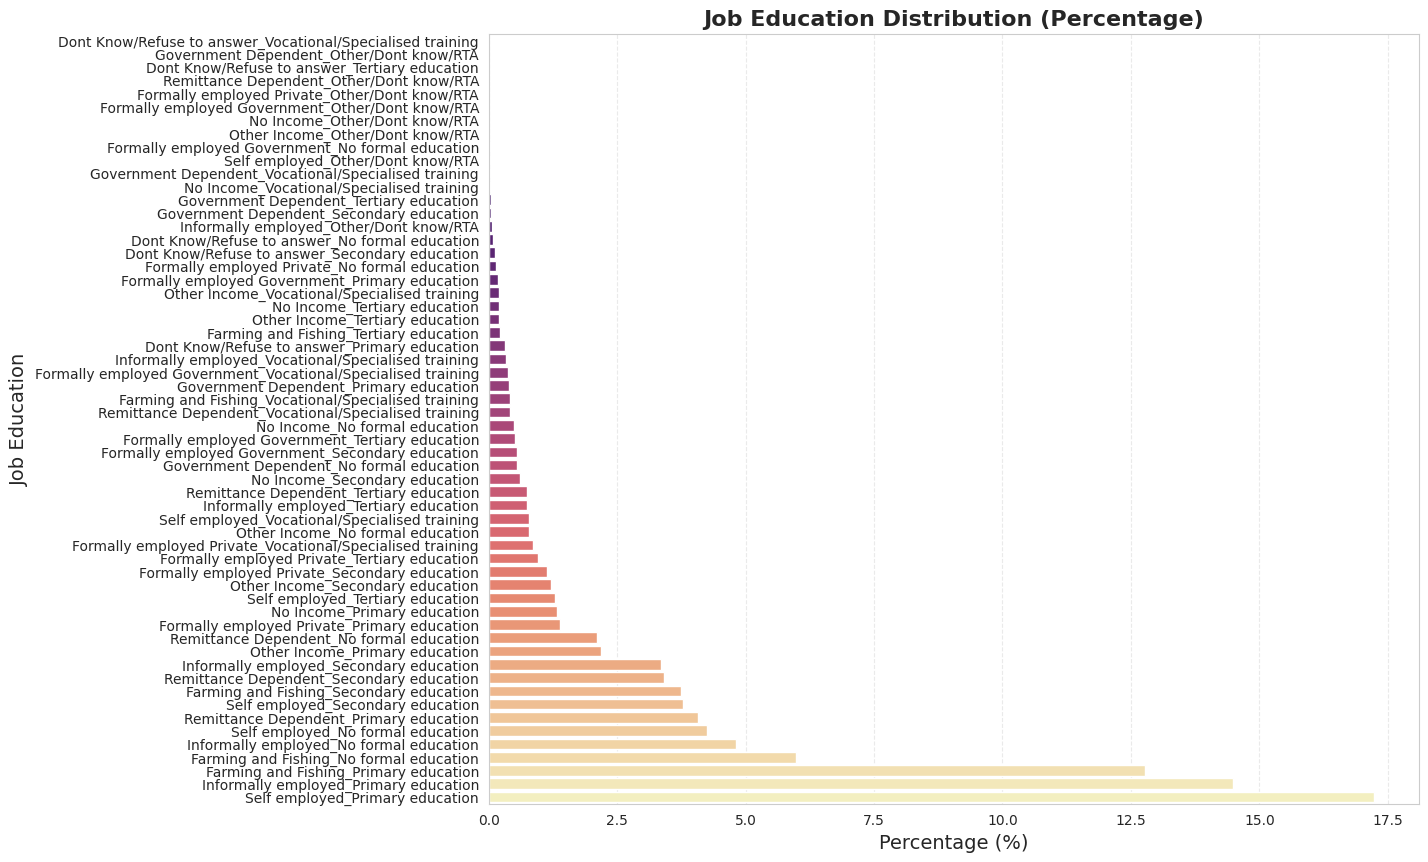

In [356]:
# Calculate percentage distribution
job_edu_counts = train['job_education'].value_counts()
job_edu_percentages = (job_edu_counts / job_edu_counts.sum()) * 100

# Create DataFrame for plotting
job_edu_df = job_edu_percentages.reset_index()
job_edu_df.columns = ['job_education', 'percentage']

# Sort for better visualization
job_edu_df = job_edu_df.sort_values('percentage', ascending=True)

# Plot horizontal bar chart (better readability for long categories)
plt.figure(figsize=(12, 10))

sns.barplot(
    data=job_edu_df,
    x='percentage',
    y='job_education',
    palette='magma'   # different color style
)

# Add labels and title
plt.xlabel('Percentage (%)', fontsize=14)
plt.ylabel('Job Education', fontsize=14)
plt.title('Job Education Distribution (Percentage)', fontsize=16, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

In [357]:
train.head()

,country,year,bank_account,location_type,cellphone_access,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,household_size_group,age_of_respondent_log,job_education
0,Kenya,2018,Yes,Rural,Yes,Female,Spouse,Married/Living together,Secondary education,Self employed,Medium (3-4),3.218876,Self employed_Secondary education
1,Kenya,2018,No,Rural,No,Female,Head of Household,Widowed,No formal education,Government Dependent,Large (5-6),4.262680,Government Dependent_No formal education
2,Kenya,2018,Yes,Urban,Yes,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed,Large (5-6),3.295837,Self employed_Vocational/Specialised training
3,Kenya,2018,No,Rural,Yes,Female,Head of Household,Married/Living together,Primary education,Formally employed Private,Large (5-6),3.555348,Formally employed Private_Primary education
4,Kenya,2018,No,Urban,No,Male,Child,Single/Never Married,Primary education,Informally employed,Very Large (7-10),3.295837,Informally employed_Primary education


## Geographic_Area

In [358]:
train['geographical_location'] = train['country'] + '_' + train['location_type']


In [359]:
test['geographical_location'] = test['country'] + '_' + test['location_type']

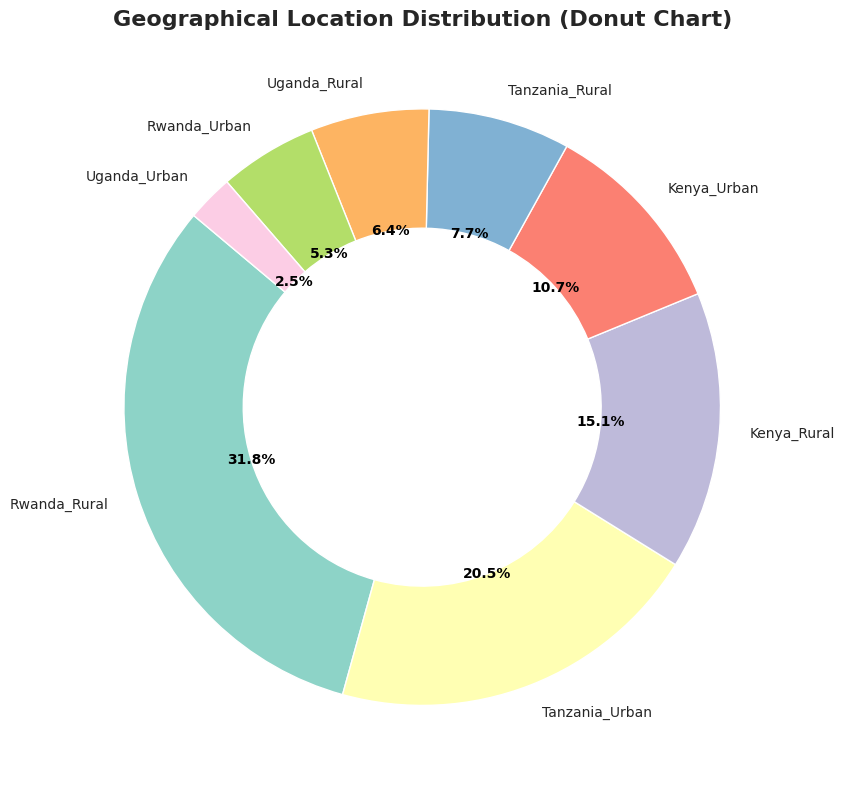

In [360]:
# Calculate percentage distribution
geo_counts = train['geographical_location'].value_counts()
geo_percentages = (geo_counts / geo_counts.sum()) * 100

# Create donut chart
plt.figure(figsize=(10, 8))

colors = sns.color_palette('Set3', len(geo_counts))  # new color palette

wedges, texts, autotexts = plt.pie(
    geo_percentages,
    labels=geo_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'width': 0.4}  # 👈 makes it a donut
)

# Style percentage text
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

# Title
plt.title('Geographical Location Distribution (Donut Chart)', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

In [361]:
train.head()

,country,year,bank_account,location_type,cellphone_access,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,household_size_group,age_of_respondent_log,job_education,geographical_location
0,Kenya,2018,Yes,Rural,Yes,Female,Spouse,Married/Living together,Secondary education,Self employed,Medium (3-4),3.218876,Self employed_Secondary education,Kenya_Rural
1,Kenya,2018,No,Rural,No,Female,Head of Household,Widowed,No formal education,Government Dependent,Large (5-6),4.262680,Government Dependent_No formal education,Kenya_Rural
2,Kenya,2018,Yes,Urban,Yes,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed,Large (5-6),3.295837,Self employed_Vocational/Specialised training,Kenya_Urban
3,Kenya,2018,No,Rural,Yes,Female,Head of Household,Married/Living together,Primary education,Formally employed Private,Large (5-6),3.555348,Formally employed Private_Primary education,Kenya_Rural
4,Kenya,2018,No,Urban,No,Male,Child,Single/Never Married,Primary education,Informally employed,Very Large (7-10),3.295837,Informally employed_Primary education,Kenya_Urban


## Demographic_Group

In [362]:
train['age_gender'] = train['age_of_respondent_log'].astype(str) + '_' + train['gender_of_respondent']

In [363]:
test['age_gender'] = test['age_of_respondent_log'].astype(str) + '_' + test['gender_of_respondent']

In [364]:
train.head()

,country,year,bank_account,location_type,cellphone_access,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,household_size_group,age_of_respondent_log,job_education,geographical_location,age_gender
0,Kenya,2018,Yes,Rural,Yes,Female,Spouse,Married/Living together,Secondary education,Self employed,Medium (3-4),3.218876,Self employed_Secondary education,Kenya_Rural,3.2188758248682006_Female
1,Kenya,2018,No,Rural,No,Female,Head of Household,Widowed,No formal education,Government Dependent,Large (5-6),4.262680,Government Dependent_No formal education,Kenya_Rural,4.2626798770413155_Female
2,Kenya,2018,Yes,Urban,Yes,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed,Large (5-6),3.295837,Self employed_Vocational/Specialised training,Kenya_Urban,3.295836866004329_Male
3,Kenya,2018,No,Rural,Yes,Female,Head of Household,Married/Living together,Primary education,Formally employed Private,Large (5-6),3.555348,Formally employed Private_Primary education,Kenya_Rural,3.5553480614894135_Female
4,Kenya,2018,No,Urban,No,Male,Child,Single/Never Married,Primary education,Informally employed,Very Large (7-10),3.295837,Informally employed_Primary education,Kenya_Urban,3.295836866004329_Male


In [365]:
train.columns

Index(['country', 'year', 'bank_account', 'location_type', 'cellphone_access',
       'gender_of_respondent', 'relationship_with_head', 'marital_status',
       'education_level', 'job_type', 'household_size_group',
       'age_of_respondent_log', 'job_education', 'geographical_location',
       'age_gender'],
      dtype='object')

In [366]:
# Label encoding the `bank_account` column
train['bank_account'] = train['bank_account'].map({'No': 0, 'Yes': 1})
train['bank_account'].value_counts()

,count
bank_account,
0,20212
1,3312


In [372]:
# One hot encoding the categorical columns and splitting the dataset into train and test sets
from sklearn.model_selection import train_test_split

# Store unique IDs from the original test set for submission
submission_unique_ids = test['uniqueid']

# Drop 'uniqueid' from the test set as it's not a feature for the model
test_features = test.drop(columns=['uniqueid'])

# Prepare the training features (X) and target (y)
# 'train' dataframe already has 'bank_account' mapped to 0/1 and 'uniqueid' dropped
train_features = train.drop(columns=['bank_account'])
y = train['bank_account']

# Combine train and test features before one-hot encoding to ensure consistent columns
combined_data_for_ohe = pd.concat([train_features, test_features], ignore_index=True)

# Identify categorical columns that need one-hot encoding
# Include 'object' and 'category' dtypes
categorical_columns = combined_data_for_ohe.select_dtypes(include=['object', 'category']).columns

# One-hot encode the categorical columns (drop first to avoid multicollinearity)
combined_data_encoded = pd.get_dummies(combined_data_for_ohe, columns=categorical_columns, drop_first=True)

# Split the combined data back into training features (X) and submission test features (X_submission_test)
X = combined_data_encoded.iloc[:len(train_features)]
X_submission_test = combined_data_encoded.iloc[len(train_features):]

# Split the training data (X, y) into train and validation sets for model training and evaluation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [369]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, mean_absolute_error, f1_score, roc_auc_score
from catboost import CatBoostClassifier

# Define constants for robust validation
SEED = 42
FOLDS = 5
SEED_LIST = [42, 2024, 3407]


In [377]:
# Install imblearn for SMOTE
!pip install imblearn


In [378]:
from imblearn.over_sampling import SMOTE


## Model Training with CatBoost and Stratified K-Fold

This section defines and trains a CatBoost Classifier using Stratified K-Fold cross-validation. This approach helps in building a more robust model by training and evaluating it on different subsets of the data, ensuring that the class distribution is maintained within each fold.

In [370]:
def train_catboost_model(X_train_data, y_train_data, X_test_data):
    oof_preds = np.zeros(len(X_train_data))
    test_preds = np.zeros(len(X_test_data))

    for seed in SEED_LIST:
        skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=seed)

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_data, y_train_data)):
            x_tr, x_val = X_train_data.iloc[train_idx], X_train_data.iloc[val_idx]
            y_tr, y_val = y_train_data.iloc[train_idx], y_train_data.iloc[val_idx]

            model = CatBoostClassifier(
                iterations=1500,
                depth=5,
                learning_rate=0.03,
                verbose=0,
                random_seed=seed,
                eval_metric='AUC'
            )

            model.fit(x_tr, y_tr, eval_set=(x_val, y_val), early_stopping_rounds=50, use_best_model=True)

            oof_preds[val_idx] += model.predict_proba(x_val)[:, 1]
            test_preds += model.predict_proba(X_test_data)[:, 1]

    oof_preds /= len(SEED_LIST)
    test_preds /= (len(SEED_LIST) * FOLDS)

    return oof_preds, test_preds


In [379]:
def train_catboost_model(X_train_data, y_train_data, X_test_data):
    oof_preds = np.zeros(len(X_train_data))
    test_preds = np.zeros(len(X_test_data))

    smote = SMOTE(random_state=SEED) # Initialize SMOTE

    for seed in SEED_LIST:
        skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=seed)

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_data, y_train_data)):
            x_tr, x_val = X_train_data.iloc[train_idx], X_train_data.iloc[val_idx]
            y_tr, y_val = y_train_data.iloc[train_idx], y_train_data.iloc[val_idx]

            # Apply SMOTE only to the training fold
            x_tr_resampled, y_tr_resampled = smote.fit_resample(x_tr, y_tr)

            model = CatBoostClassifier(
                iterations=1500,
                depth=5,
                learning_rate=0.03,
                verbose=0,
                random_seed=seed,
                eval_metric='AUC'
            )

            model.fit(x_tr_resampled, y_tr_resampled, eval_set=(x_val, y_val), early_stopping_rounds=50, use_best_model=True)

            oof_preds[val_idx] += model.predict_proba(x_val)[:, 1]
            test_preds += model.predict_proba(X_test_data)[:, 1]

    oof_preds /= len(SEED_LIST)
    test_preds /= (len(SEED_LIST) * FOLDS)

    return oof_preds, test_preds


## Model Training with LightGBM and Stratified K-Fold

This section defines and trains a LightGBM Classifier using Stratified K-Fold cross-validation with SMOTE. This will allow us to compare its performance with the CatBoost model.

In [391]:
def train_lightgbm_model(X_train_data, y_train_data, X_test_data):
    oof_preds = np.zeros(len(X_train_data))
    test_preds = np.zeros(len(X_test_data))

    smote = SMOTE(random_state=SEED) # Initialize SMOTE

    for seed in SEED_LIST:
        skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=seed)

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_data, y_train_data)):
            x_tr, x_val = X_train_data.iloc[train_idx], X_train_data.iloc[val_idx]
            y_tr, y_val = y_train_data.iloc[train_idx], y_train_data.iloc[val_idx]

            # Apply SMOTE only to the training fold
            x_tr_resampled, y_tr_resampled = smote.fit_resample(x_tr, y_tr)

            model = LGBMClassifier(
                objective='binary',
                metric='auc',
                n_estimators=1500,
                learning_rate=0.03,
                num_leaves=31,
                max_depth=5,
                random_state=seed,
                n_jobs=-1
            )

            model.fit(x_tr_resampled, y_tr_resampled,
                      eval_set=[(x_val, y_val)],
                      eval_metric='auc',
                      callbacks=[lgb.early_stopping(50, verbose=False)]) # Corrected early stopping callback

            oof_preds[val_idx] += model.predict_proba(x_val)[:, 1]
            test_preds += model.predict_proba(X_test_data)[:, 1]

    oof_preds /= len(SEED_LIST)
    test_preds /= (len(SEED_LIST) * FOLDS)

    return oof_preds, test_preds


## Training and Evaluation (LightGBM)

Now, let's train the LightGBM model and evaluate its performance.

In [392]:
# Train the LightGBM model on the training split and evaluate on the validation split
lightgbm_oof, lightgbm_val_preds = train_lightgbm_model(X_train, y_train, X_val)

# Evaluate OOF predictions (from validation sets during training)
lightgbm_oof_binary_preds = (lightgbm_oof > 0.5).astype(int)
lightgbm_val_binary_preds = (lightgbm_val_preds > 0.5).astype(int)

print(f"LightGBM OOF MAE: {mean_absolute_error(y_train, lightgbm_oof_binary_preds):.4f}")
print(f"LightGBM Validation Accuracy: {accuracy_score(y_val, lightgbm_val_binary_preds):.4f}")
print(f"LightGBM Validation F1 Score: {f1_score(y_val, lightgbm_val_binary_preds):.4f}")
print(f"LightGBM OOF ROC AUC: {roc_auc_score(y_train, lightgbm_oof):.4f}")

# Store results for comparison
results.append([
    "LightGBM",
    mean_absolute_error(y_train, lightgbm_oof_binary_preds),
    accuracy_score(y_val, lightgbm_val_binary_preds),
    f1_score(y_val, lightgbm_val_binary_preds),
    roc_auc_score(y_train, lightgbm_oof)
])

results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'Accuracy', 'F1 Score', 'ROC AUC'])
display(results_df)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 12935, number of negative: 12935
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 690
[LightGBM] [Info] Number of data points in the train set: 25870, number of used features: 218
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

,Model,MAE,Accuracy,F1 Score,ROC AUC
0,Logistic Regression,0.213177,0.786823,0.502233,0.864630
1,Random Forest,0.141764,0.858236,0.475216,0.827813
2,XGBoost,0.195962,0.804038,0.517277,0.858443
3,CatBoost,0.110733,0.889267,0.489716,0.877510
4,LightGBM,0.161326,0.842721,0.547677,0.853999


## Training and Evaluation

Now, let's train the model and evaluate its performance using various metrics.

In [393]:
# Train the CatBoost model on the training split and evaluate on the validation split
oof, val_preds = train_catboost_model(X_train, y_train, X_val)

# Evaluate OOF predictions (from validation sets during training)
oof_binary_preds = (oof > 0.5).astype(int)
val_binary_preds = (val_preds > 0.5).astype(int)

print(f"OOF MAE: {mean_absolute_error(y_train, oof_binary_preds):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, val_binary_preds):.4f}")
print(f"Validation F1 Score: {f1_score(y_val, val_binary_preds):.4f}")
print(f"OOF ROC AUC: {roc_auc_score(y_train, oof):.4f}")

OOF MAE: 0.1632
Validation Accuracy: 0.8374
Validation F1 Score: 0.5422
OOF ROC AUC: 0.8557


## Feature Importance Analysis

To understand which features are most influential in predicting bank account ownership, we will train a final CatBoost model on the entire training dataset and analyze its feature importances.

In [394]:
# Train a final CatBoost model on the full training data to get feature importances
final_model = CatBoostClassifier(
    iterations=1500,
    depth=5,
    learning_rate=0.03,
    verbose=0,
    random_seed=SEED,
    eval_metric='AUC'
)

final_model.fit(X, y)

# Get feature importances
feature_importance = final_model.get_feature_importance()
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top 15 most important features
display(importance_df.head(15))


,Feature,Importance
6,cellphone_access_Yes_True,20.891147
1,age_of_respondent_log,8.526832
20,education_level_Tertiary education_True,5.119372
19,education_level_Secondary education_True,3.951364
0,year,3.765954
39,geographical_location_Tanzania_Urban_True,3.765210
21,education_level_Vocational/Specialised trainin...,3.546987
24,job_type_Formally employed Private_True,3.185797
35,geographical_location_Kenya_Urban_True,2.638036
3,country_Tanzania_True,2.350461


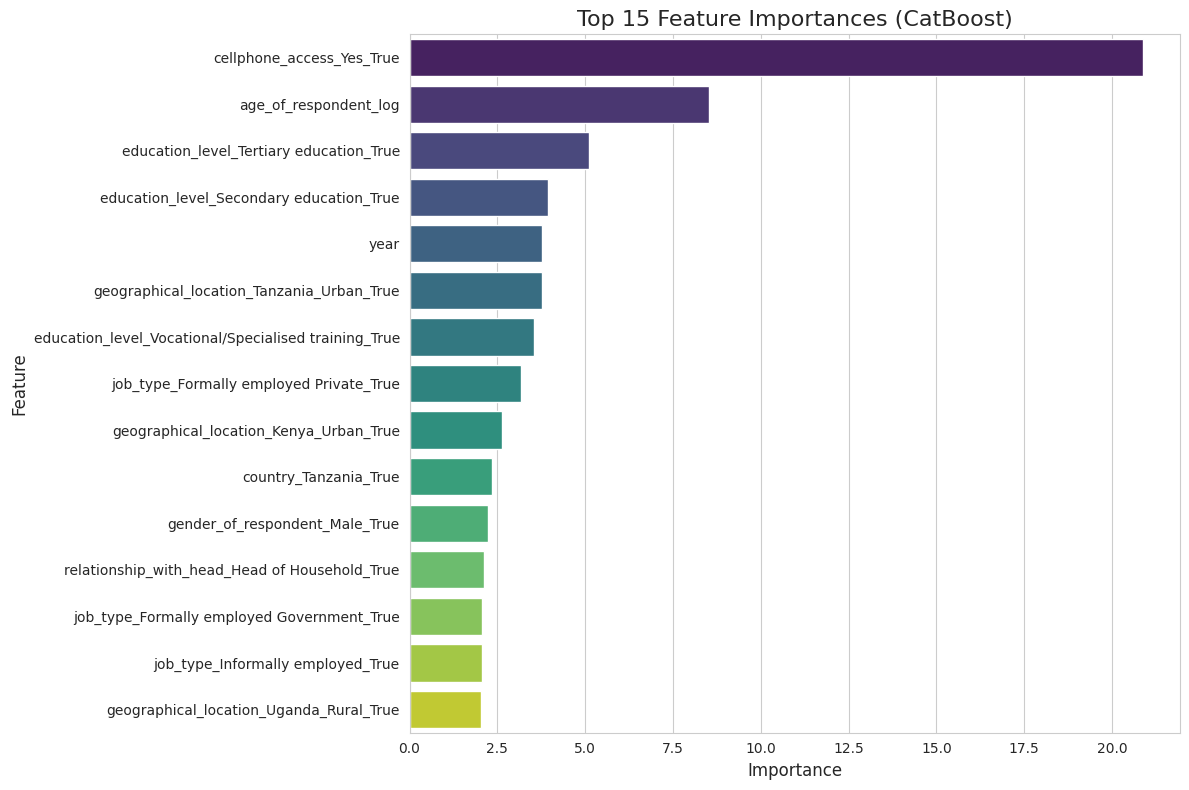

In [395]:
# Visualize the top 15 feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances (CatBoost)', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()


## Generate Submission File

Now, we will use the trained CatBoost model to predict the `bank_account` status for the `test` dataset and generate a `submission.csv` file in the required format.

In [396]:
# To predict on the actual submission test set, we need to retrain the model on the full training data (X, y)
# and then predict on X_submission_test.
# However, the current train_catboost_model function already returns `test_preds` which were computed during the K-Fold training.
# Let's re-run train_catboost_model to get predictions for X_submission_test.

# NOTE: The current train_catboost_model function's `test_preds` parameter is designed to predict on a validation set (X_test_data).
# To get predictions for the *actual* submission file, we need to pass X_submission_test as the X_test_data parameter.
# I will modify the function call to reflect this, and also train on the full X, y to get more robust predictions for submission.

# Retrain the model on the full X and y and get predictions for X_submission_test
_, final_test_preds = train_catboost_model(X, y, X_submission_test)

# Convert probabilities to binary predictions (0 or 1)
final_predictions_binary = (final_test_preds > 0.5).astype(int)

# Create the submission DataFrame
submission_df = pd.DataFrame({
    'uniqueid': submission_unique_ids,
    'bank_account': final_predictions_binary
})

# Map 0/1 back to 'No'/'Yes' as required by the sample submission format
# submission_df['bank_account'] = submission_df['bank_account'].map({0: 'No', 1: 'Yes'})

# Ensure unique_id has the correct format for submission
# The original submission_unique_ids are just the uniqueid part, so we need to combine with country for the final submission format

# Retrieve original uniqueid and country from the test dataframe to recreate the 'unique_id x country' format
# Assuming `test` dataframe still holds original 'uniqueid' and 'country' columns
original_test_df = pd.read_csv(path + "Test.csv") # Reload original test to get 'uniqueid' and 'country'
submission_df['uniqueid'] = original_test_df['uniqueid'].astype(str) + ' x ' + original_test_df['country'].astype(str)

# Rename 'uniqueid' column to 'unique_id' to match submission format
submission_df.rename(columns={'uniqueid': 'unique_id'}, inplace=True)

# Save the submission file
submission_filename = 'submission.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"Submission file '{submission_filename}' created successfully.")
print(submission_df.head())

Submission file 'submission.csv' created successfully.
               unique_id  bank_account
0  uniqueid_6056 x Kenya             0
1  uniqueid_6060 x Kenya             0
2  uniqueid_6065 x Kenya             0
3  uniqueid_6072 x Kenya             0
4  uniqueid_6073 x Kenya             0


In [397]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Ensemble Modeling: VotingClassifier

To further improve performance and robustness, we will create an ensemble model using `VotingClassifier` to combine the predictions of the CatBoost and LightGBM models. This approach leverages the strengths of both models.

We will integrate `SMOTE` into pipelines for each base estimator to ensure the class imbalance is handled consistently within the ensemble training.

In [401]:
from sklearn.ensemble import VotingClassifier
from imblearn.pipeline import Pipeline as ImbPipeline # Import ImbPipeline from imblearn

# Define the base models with their best-performing hyperparameters
cat_model_base = CatBoostClassifier(
    iterations=1500,
    depth=5,
    learning_rate=0.03,
    verbose=0,
    random_seed=SEED,
    eval_metric='AUC',
    early_stopping_rounds=50 # Early stopping applied during fit
)

lgbm_model_base = LGBMClassifier(
    objective='binary',
    metric='auc',
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=5,
    random_state=SEED,
    n_jobs=-1,
    callbacks=[lgb.early_stopping(50, verbose=False)] # Early stopping applied during fit
)

# Create pipelines for each model, including SMOTE using ImbPipeline
cat_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=SEED)),
    ('catboost', cat_model_base)
])

lgbm_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=SEED)),
    ('lightgbm', lgbm_model_base)
])

# Create the VotingClassifier
voting_clf = VotingClassifier(
    estimators=[
        ('catboost', cat_pipeline),
        ('lightgbm', lgbm_pipeline)
    ],
    voting='soft', # 'soft' for probability prediction
    weights=[0.5, 0.5], # Equal weights for now, can be tuned
    n_jobs=-1
)

# Train the VotingClassifier on the training data
print("Training VotingClassifier...")
voting_clf.fit(X_train, y_train)
print("VotingClassifier training complete.")

Training VotingClassifier...
VotingClassifier training complete.


In [404]:
# Evaluate the VotingClassifier on the validation set
voting_val_preds_proba = voting_clf.predict_proba(X_val)[:, 1]
voting_val_binary_preds = (voting_val_preds_proba > 0.5).astype(int)

print(f"VotingClassifier Validation Accuracy: {accuracy_score(y_val, voting_val_binary_preds):.4f}")
print(f"VotingClassifier Validation F1 Score: {f1_score(y_val, voting_val_binary_preds):.4f}")
print(f"VotingClassifier Validation ROC AUC: {roc_auc_score(y_val, voting_val_preds_proba):.4f}")

# Add results to the comparison DataFrame
results.append([
    "VotingClassifier",
    mean_absolute_error(y_val, voting_val_binary_preds), # Using MAE on val for consistency
    accuracy_score(y_val, voting_val_binary_preds),
    f1_score(y_val, voting_val_binary_preds),
    roc_auc_score(y_val, voting_val_preds_proba)
])

results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'Accuracy', 'F1 Score', 'ROC AUC'])
display(results_df)

[LightGBM] [Warning] Unknown parameter: callbacks
[LightGBM] [Warning] Unknown parameter: 0x79f0c9188da0>
[LightGBM] [Warning] Unknown parameter: at
[LightGBM] [Warning] Unknown parameter: object
VotingClassifier Validation Accuracy: 0.8755
VotingClassifier Validation F1 Score: 0.5342
VotingClassifier Validation ROC AUC: 0.8692


,Model,MAE,Accuracy,F1 Score,ROC AUC
0,Logistic Regression,0.213177,0.786823,0.502233,0.864630
1,Random Forest,0.141764,0.858236,0.475216,0.827813
2,XGBoost,0.195962,0.804038,0.517277,0.858443
3,CatBoost,0.110733,0.889267,0.489716,0.877510
4,LightGBM,0.161326,0.842721,0.547677,0.853999
5,VotingClassifier,0.124548,0.875452,0.534181,0.869176
6,VotingClassifier,0.124548,0.875452,0.534181,0.869176


## Generate Submission File with VotingClassifier

Finally, we will use the trained `VotingClassifier` to predict bank account status for the `test` dataset and generate the final submission file.

In [406]:
# Predict on the actual submission test set
final_voting_preds_proba = voting_clf.predict_proba(X_submission_test)[:, 1]
final_voting_predictions_binary = (final_voting_preds_proba > 0.2).astype(int) # Changed threshold to 0.2

# Create the submission DataFrame
submission_df_voting = pd.DataFrame({
    'uniqueid': submission_unique_ids,
    'bank_account': final_voting_predictions_binary
})

# Retrieve original uniqueid and country from the test dataframe to recreate the 'unique_id x country' format
# original_test_df is already loaded if the previous cell was run, but reloading to be safe
original_test_df = pd.read_csv(path + "Test.csv")
submission_df_voting['uniqueid'] = original_test_df['uniqueid'].astype(str) + ' x ' + original_test_df['country'].astype(str)

# Rename 'uniqueid' column to 'unique_id' to match submission format
submission_df_voting.rename(columns={'uniqueid': 'unique_id'}, inplace=True)

# Save the submission file
submission_filename_voting = 'submission_voting_classifier_threshold_02.csv' # Changed filename
submission_df_voting.to_csv(submission_filename_voting, index=False)

print(f"Submission file '{submission_filename_voting}' created successfully.")
display(submission_df_voting.head())

from google.colab import files
files.download(submission_filename_voting)

[LightGBM] [Warning] Unknown parameter: callbacks
[LightGBM] [Warning] Unknown parameter: 0x79f0c0cc1a30>
[LightGBM] [Warning] Unknown parameter: at
[LightGBM] [Warning] Unknown parameter: object
Submission file 'submission_voting_classifier_threshold_02.csv' created successfully.


,unique_id,bank_account
0,uniqueid_6056 x Kenya,0
1,uniqueid_6060 x Kenya,0
2,uniqueid_6065 x Kenya,0
3,uniqueid_6072 x Kenya,0
4,uniqueid_6073 x Kenya,0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>